In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("housing.csv")

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

Saving Housing.csv to Housing.csv


## Data Exploration and Preprocessing

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.shape

(545, 13)

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [8]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [9]:
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [10]:
df_clean = df.dropna()

In [ ]:
df['price'] = df['price'].fillna(df['price'].mean())

df['prefarea'] = df['prefarea'].fillna(df['prefarea'].mode()[0])

In [11]:
df.duplicated().sum() 


np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [4]:
binary_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


C:\Users\hasan\AppData\Local\Temp\ipykernel_8556\1715433512.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


In [5]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)


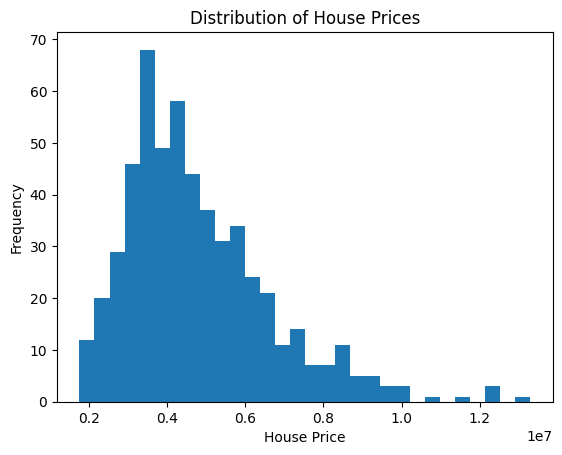

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=30)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()


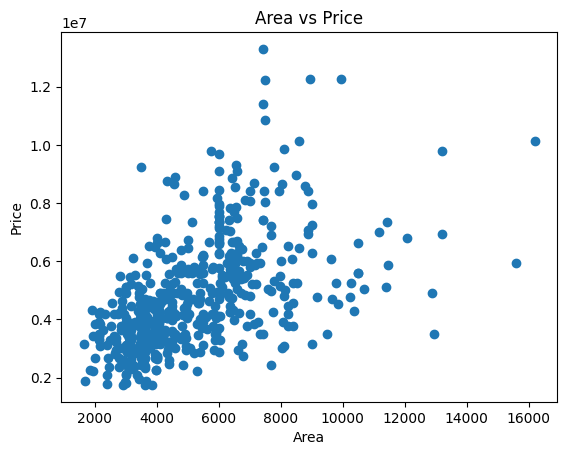

In [7]:
plt.scatter(df['area'], df['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()


In [8]:
corr_matrix = df.corr()

corr_matrix['price'].sort_values(ascending=False)


price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

# Multiple Linear Regression

In [9]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)


LinearRegression()

In [11]:
y_pred = mlr.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.6529242642153186
RMSE: 1324506.9600914384


R² Score = 0.653  

Interpretation:  

The multiple linear regression model explains approximately 65.3% of the variance in house prices.  

This is a substantial improvement over Simple Linear Regression.  

In [12]:
# Feature Importance (Coefficients)

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr.coef_
}).sort_values(by='Coefficient', ascending=False)

coeff_df


,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


| Feature             | Coefficient | Interpretation                                                      |
| ------------------- | ----------- | ------------------------------------------------------------------- |
| **bathrooms**       | 1,094,445   | Adding one bathroom **increases price by ~1.09 million**            |
| **airconditioning** | 791,427     | Houses with AC are ~0.79 million higher in price                    |
| **hotwaterheating** | 684,650     | Hot water heating adds ~0.68 million                                |
| **prefarea**        | 629,891     | Houses in preferred areas are ~0.63 million higher                  |
| **stories**         | 407,477     | Each additional story increases price by ~0.41 million              |
| **basement**        | 390,251     | Having a basement adds ~0.39 million                                |
| **mainroad**        | 367,920     | Main road frontage adds ~0.37 million                               |
| **guestroom**       | 231,610     | Guestroom adds ~0.23 million                                        |
| **parking**         | 224,842     | Parking adds ~0.22 million                                          |
| **bedrooms**        | 76,779      | Each bedroom adds ~0.077 million                                    |
| **area**            | 236         | Minimal impact individually when controlling for all other features |


| Feature                             | Coefficient | Interpretation                                                               |
| ----------------------------------- | ----------- | ---------------------------------------------------------------------------- |
| **furnishingstatus_semi-furnished** | -126,882    | Semi-furnished houses are ~0.127 million cheaper than fully furnished houses |
| **furnishingstatus_unfurnished**    | -413,645    | Unfurnished houses are ~0.41 million cheaper than fully furnished houses     |


Key Insights  

Bathrooms, AC, and hot water heating have the largest impact on price.  

Area’s coefficient drops dramatically (from 425 in SLR to 236) because its effect overlaps with other structural features (multicollinearity).  

Negative Coefficients: Makes perfect sense: furnishing increases price, with “furnished” as the baseline.  

The multiple linear regression model shows that bathrooms, air conditioning, and hot water heating have the largest positive impact on housing prices. Preferred location,   stories, and basement also add significant value. Furnishing status has a negative coefficient for semi- or unfurnished houses, confirming that fully furnished houses are   
priced higher. Interestingly, the effect of area is minimal in the multivariate context due to multicollinearity with other structural features.  

Housing Price Indicators (HPIs) are measurable factors that influence the market value of a house.  
From a business perspective, HPIs help real-estate developers, investors, and buyers understand why one property is priced higher than another.  

In simple terms:  

HPIs are the key features that drive house prices.  
HPIs in Your Housing Dataset (Solution-Oriented)  

Based on your regression and correlation results, the following are the main HPIs:  

1. Structural HPIs (Physical Characteristics)  

Area – Size of the house  
Bedrooms – Living capacity  
Bathrooms – Strong value driver  
Stories – Multi-level property premium  

2. Amenity-Based HPIs (Comfort & Facilities)  

Air Conditioning – Comfort and livability  
Hot Water Heating – Quality of living  
Parking – Convenience factor  
Basement / Guestroom – Additional usable space  

3. Location-Based HPIs  

Preferred Area (prefarea) – Desirable neighborhood  
Main Road Access (mainroad) – Accessibility and visibility  

4. Quality & Market Positioning HPIs  

Furnishing Status  
Furnished → Highest value  
Semi-furnished → Moderate value  
Unfurnished → Lower value  

In [14]:
new_house = pd.DataFrame([{
    'area': 1500,
    'bedrooms': 3,
    'bathrooms': 3,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 0,
    'hotwaterheating': 1,
    'airconditioning': 1,
    'parking': 0,
    'prefarea': 1,
    'furnishingstatus_semi-furnished': 0,
    'furnishingstatus_unfurnished': 0
}])

predicted_price = mlr.predict(new_house)

print("Predicted price for new house:", predicted_price[0])


Predicted price for new house: 7416496.351769162


Existing House (Actual)  
Price: 3,150,000  
Area: 1650  
Bedrooms: 3  
Bathrooms: 1  
Stories: 2  
Mainroad: No  
Guestroom: No  
Basement: Yes  
Hot water: No  
Airconditioning: No  
Parking: 0  
Preferred area: No  
Furnishing: Unfurnished  


New House (Prediction Input)  
Area: 1500  
Bedrooms: 3  
Bathrooms: 3   ⬆⬆⬆  
Stories: 2  
Mainroad: Yes  ⬆  
Guestroom: No  
Basement: No  
Hot water: Yes ⬆  
Airconditioning: Yes ⬆  
Parking: 0  
Preferred area: Yes ⬆  
Furnishing: Furnished ⬆  


Key Drivers of the Large Price Increase  

From your MLR coefficients:  

| Feature              | Coefficient | Impact                          |
| -------------------- | ----------- | ------------------------------- |
| Bathrooms            | +1,094,445  | **+2 extra bathrooms ≈ +2.19M** |
| Air Conditioning     | +791,427    | +0.79M                          |
| Hot Water Heating    | +684,650    | +0.68M                          |
| Preferred Area       | +629,891    | +0.63M                          |
| Furnished (baseline) | +413,645    | vs unfurnished                  |
| Main Road            | +367,920    | +0.37M                          |
